In [38]:
import numpy as np
from sklearn.datasets import fetch_lfw_people
dataset = fetch_lfw_people(min_faces_per_person=80)
count, height, width = dataset.images.shape
print('The dataset type is:',type(dataset.images))
print('The number of images in the dataset:',count)
print('The height of each image:',height)
print('The width of each image:',width)
print('The shape of data is:',dataset.data.shape)

The dataset type is: <class 'numpy.ndarray'>
The number of images in the dataset: 1140
The height of each image: 62
The width of each image: 47
The shape of data is: (1140, 2914)


In [39]:
X = dataset.data
y = dataset.target

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
data = load_iris()
X = data.data   # Features
y = data.target # Labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scalar_value = StandardScaler()

X_scalar_train = scalar_value.fit_transform(X_train)

X_scalar_test = scalar_value.transform(X_test)

for i in X_scalar_train[0:5]:
    print(i[0:5])


[-1.01827123  1.2864604  -1.39338902 -1.3621769 ]
[-0.7730102   2.43545215 -1.33550342 -1.49647603]
[-0.03722712 -0.78172474  0.74837808  0.92090833]
[0.20803391 0.8268637  0.4010645  0.51801093]
[1.06644751 0.13746866 0.51683569 0.3837118 ]


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

data = load_iris()
X = data.data  
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scalar_value = StandardScaler()

X_scalar_train = scalar_value.fit_transform(X_train)

n_components = 4  # Set n_components to 4 as there are only 4 features
pca = PCA(n_components=n_components, whiten=True, svd_solver="randomized")

pca.fit(X_scalar_train)
X_pca = pca.transform(X_scalar_train)

print(f"Shape of X_pca: {X_pca.shape}")


Shape of X_pca: (112, 4)


In [42]:
import matplotlib.pyplot as plt
def plot_gallery(images, titles, height, width, n_row=2, n_col=4):
    plt.figure(figsize=(2* n_col, 3 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((height, width)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

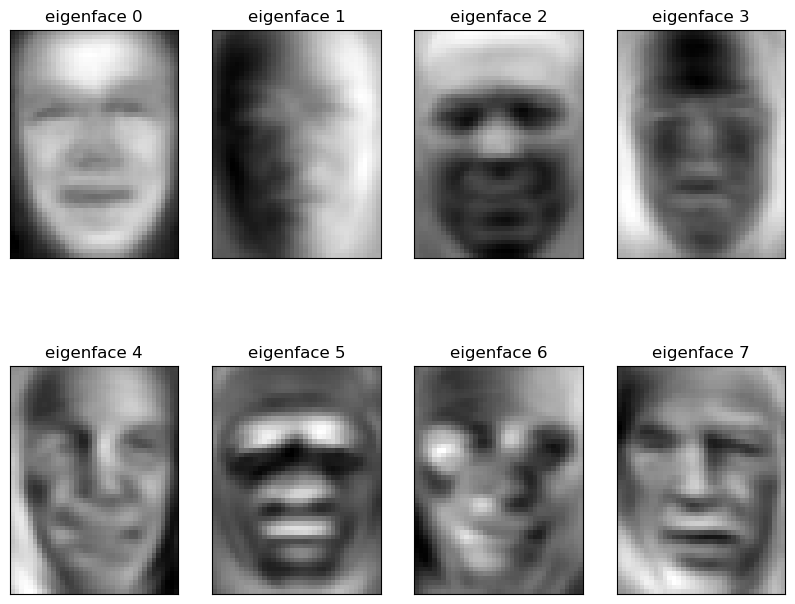

In [43]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

X = faces.data 
y = faces.target 
height, width = faces.images.shape[1], faces.images.shape[2]

scalar_value = StandardScaler()
X_scaled = scalar_value.fit_transform(X)
n_components = 100
pca = PCA(n_components=n_components, whiten=True, svd_solver="randomized")
pca.fit(X_scaled)
eigenfaces = pca.components_.reshape((n_components, height, width))

eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]

def plot_gallery(images, titles, h, w):
    plt.figure(figsize=(10, 8))
    for i in range(min(images.shape[0], 8)):  # Plot the top 8 eigenfaces
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i], cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

plot_gallery(eigenfaces, eigenface_titles, height, width)

plt.show()


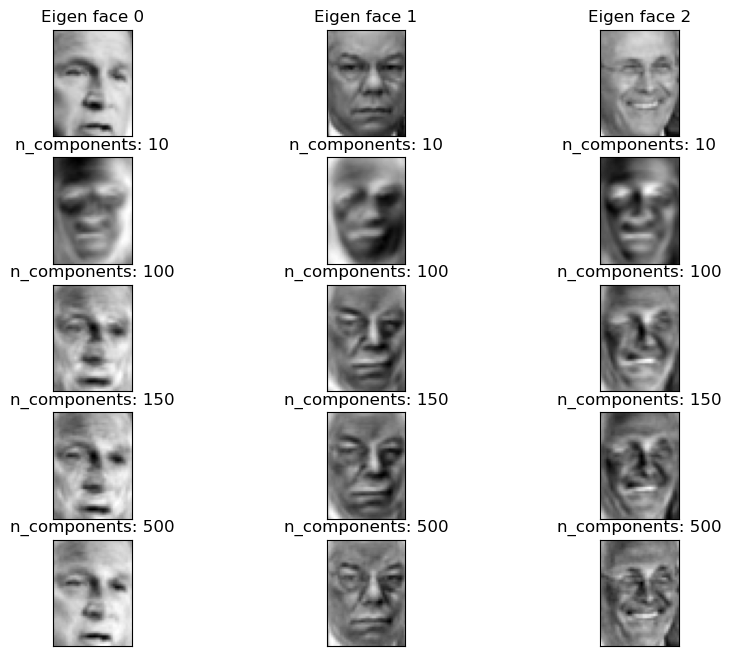

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X = faces.data
y = faces.target
height, width = faces.images.shape[1], faces.images.shape[2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scalar_value = StandardScaler()
X_scalar_train = scalar_value.fit_transform(X_train)

def transform_face(n, height, width):
    pca = PCA(n_components=n, whiten=True, svd_solver="randomized")
    pca_fit_transform = pca.fit_transform(X_scalar_train)
    pca_inverse_transform = pca.inverse_transform(pca_fit_transform)
    return pca_inverse_transform

n_components = [10, 100, 150, 500]
Faces = X_train[0:3, :]
Header = ["Eigen face %d" % i for i in range(3)]

for i in n_components:
    transformed_eigenfaces = transform_face(i, height, width)
    Header += ["n_components: " + str(i) for _ in range(3)]
    Faces = np.concatenate((Faces, transformed_eigenfaces[0:3, :]))

def plot_gallery(images, titles, h, w, n_row=5, n_col=3):
    plt.figure(figsize=(10, 8))
    for i in range(min(images.shape[0], n_row * n_col)):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape(h, w), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

plot_gallery(Faces, Header, height, width, n_row=5, n_col=3)
plt.show()


In [45]:
import torch
import torch.nn as nn

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X = faces.data  # 1850 features per image
y = faces.target
height, width = faces.images.shape[1], faces.images.shape[2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scalar_value = StandardScaler()
X_scalar_train = scalar_value.fit_transform(X_train)
X_scalar_test = scalar_value.transform(X_test)

n_components = 100
pca = PCA(n_components=n_components, whiten=True, svd_solver="randomized")
X_train_pca = pca.fit_transform(X_scalar_train)
X_test_pca = pca.transform(X_scalar_test)

X_train_pca_torch = torch.tensor(X_train_pca)
X_test_pca_torch = torch.tensor(X_test_pca)
y_train_torch = torch.tensor(y_train, dtype=torch.long)
y_test_torch = torch.tensor(y_test, dtype=torch.long)


In [47]:
class MLP(torch.nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.l1=nn.Linear(n_components,1024)
    self.l2=nn.Linear(1024,5)
    self.relu_actv=nn.ReLU()
    self.LS_max=nn.LogSoftmax()

  def forward(self, x):
    l1_x=self.l1(x)
    relu_x=self.relu_actv(l1_x)
    l2_x=self.l2(relu_x)
    l2_x=self.LS_max(l2_x)
    return l2_x

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(100, 50)
        self.fc2 = nn.Linear(50, 7)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = MLP()
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(501):
    optimizer.zero_grad()
    output = model(X_train_pca_torch)
    loss = criterion(output, y_train_torch)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item():.3f}')


Epoch: 0, Loss: 1.880
Epoch: 50, Loss: 1.278
Epoch: 100, Loss: 0.763
Epoch: 150, Loss: 0.433
Epoch: 200, Loss: 0.266
Epoch: 250, Loss: 0.181
Epoch: 300, Loss: 0.132
Epoch: 350, Loss: 0.101
Epoch: 400, Loss: 0.080
Epoch: 450, Loss: 0.066
Epoch: 500, Loss: 0.055


In [49]:
# predict on test data
predictions = model(X_test_pca_torch) # gives softmax logits
y_pred = torch.argmax(predictions, dim=1).numpy()

              precision    recall  f1-score   support

     class_0       0.73      0.62      0.67        13
     class_1       0.81      0.85      0.83        60
     class_2       0.73      0.70      0.72        27
     class_3       0.90      0.92      0.91       146
     class_4       0.70      0.76      0.73        25
     class_5       0.83      0.67      0.74        15
     class_6       0.79      0.72      0.75        36

    accuracy                           0.83       322
   macro avg       0.78      0.75      0.76       322
weighted avg       0.83      0.83      0.83       322



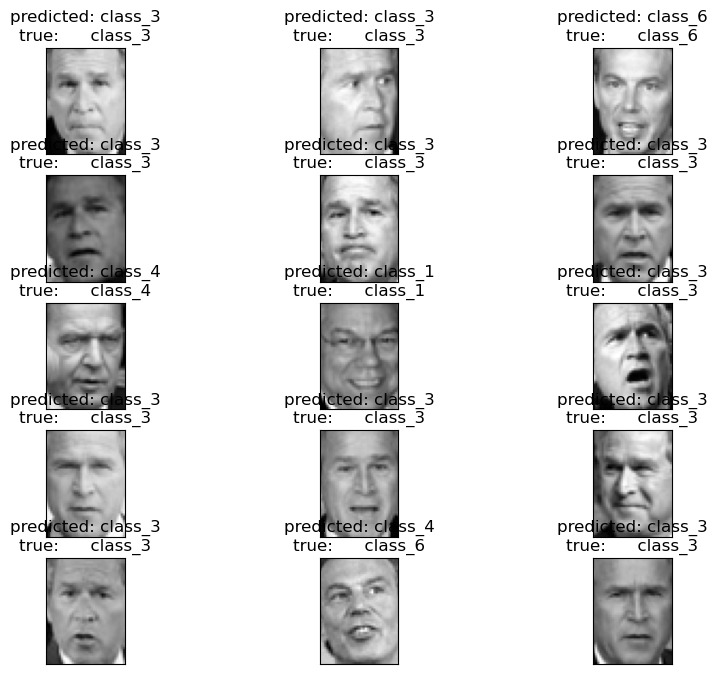

In [50]:
from sklearn.metrics import classification_report

target_names = ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6']
y_pred = model(X_test_pca_torch).argmax(dim=1).numpy()

print(classification_report(y_test, y_pred, target_names=target_names))

def title(y_pred, y_test, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(" ", 1)[-1]
    true_name = target_names[y_test[i]].rsplit(" ", 1)[-1]
    return "predicted: %s\ntrue:      %s" % (pred_name, true_name)

prediction_titles = [
    title(y_pred, y_test, target_names, i) for i in range(len(y_pred))
]

plot_gallery(X_test, prediction_titles, height, width)
